## DATA UNDERSTANDING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:/Users/SHRAWANI/Downloads/Ecommerce_Customer_Segmentation/data.csv", encoding='cp1252')

In [4]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## DATA CLEANING AND PREPROCESSING

In [11]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df = df.drop_duplicates()

In [14]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing CustomerID:", df['CustomerID'].isnull().sum())

Shape: (401604, 8)
Duplicate rows: 0
Missing CustomerID: 0


In [15]:
print("Negative Quantity:", df[df['Quantity'] < 0].shape)
print("Zero Quantity:", df[df['Quantity'] == 0].shape)
print("Negative UnitPrice:", df[df['UnitPrice'] < 0].shape)
print("Zero UnitPrice:", df[df['UnitPrice'] == 0].shape)

Negative Quantity: (8872, 8)
Zero Quantity: (0, 8)
Negative UnitPrice: (0, 8)
Zero UnitPrice: (40, 8)


In [16]:
df[df['Quantity'] < 0][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID']].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897


In [17]:
df[df['Quantity'] < 0]['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
True    8872
Name: count, dtype: int64

In [18]:
df[df['UnitPrice'] == 0][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID']].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410


In [19]:
df[df['Quantity'] < 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID']
].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897


In [20]:
df = df[df['Quantity'] > 0].copy()

In [21]:
print("Shape after removing returns/cancellations:", df.shape)
print("Negative Quantity:", (df['Quantity'] < 0).sum())

Shape after removing returns/cancellations: (392732, 8)
Negative Quantity: 0


In [22]:
print("Zero UnitPrice transactions:", (df['UnitPrice'] == 0).sum())

print("Revenue from zero-price transactions:",
      (df[df['UnitPrice'] == 0]['Quantity'] *
       df[df['UnitPrice'] == 0]['UnitPrice']).sum())

Zero UnitPrice transactions: 40
Revenue from zero-price transactions: 0.0


In [23]:
df[df['UnitPrice'] == 0][
    ['InvoiceNo', 'Description', 'Quantity', 'InvoiceDate', 'CustomerID']
].head(10)

,InvoiceNo,Description,Quantity,InvoiceDate,CustomerID
9302,537197,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,12647
33576,539263,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,16560
40089,539722,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,14911
47068,540372,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,13081
47070,540372,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,13081
56674,541109,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,15107
86789,543599,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,17560
130188,547417,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,13239
139453,548318,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,13113
145208,548871,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,14410


## FEATURE ENGINEERING 

In [24]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [25]:
print(df['Revenue'].describe())

count    392732.000000
mean         22.629195
std         311.083465
min           0.000000
25%           4.950000
50%          12.390000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


In [26]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice < 0:", (df['UnitPrice'] < 0).sum())
print("UnitPrice = 0:", (df['UnitPrice'] == 0).sum())
print("Revenue < 0:", (df['Revenue'] < 0).sum())
print("Revenue = 0:", (df['Revenue'] == 0).sum())
print("Missing values:")
print(df.isnull().sum())

Quantity <= 0: 0
UnitPrice < 0: 0
UnitPrice = 0: 40
Revenue < 0: 0
Revenue = 0: 40
Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


## EXPLORATORY DATA ANALYSIS (EDA)

In [27]:
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['StockCode'].nunique())
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Unique Countries:", df['Country'].nunique())

Unique Customers: 4339
Unique Products: 3665
Unique Invoices: 18536
Unique Countries: 37


In [28]:
print("Start Date:", df['InvoiceDate'].min())
print("End Date:", df['InvoiceDate'].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [29]:
customer_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique()

print(customer_transactions.describe())

count    4339.000000
mean        4.271952
std         7.705493
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       210.000000
Name: InvoiceNo, dtype: float64


In [30]:
print(customer_transactions.sort_values(ascending=False).head(10))

CustomerID
12748    210
14911    201
17841    124
13089     97
14606     93
15311     91
12971     86
14646     74
16029     63
13408     62
Name: InvoiceNo, dtype: int64


In [31]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

print(customer_revenue.describe())

count      4339.000000
mean       2048.215924
std        8984.248352
min           0.000000
25%         306.455000
50%         668.560000
75%        1660.315000
max      280206.020000
Name: Revenue, dtype: float64


In [32]:
print(customer_revenue.sort_values(ascending=False).head(10))

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64


In [33]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [34]:
customer_recency = (
    df.groupby('CustomerID')['InvoiceDate']
      .max()
      .apply(lambda x: (reference_date - x).days)
)

print(customer_recency.describe())

count    4339.000000
mean       92.518322
std       100.009747
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: InvoiceDate, dtype: float64


In [35]:
print(customer_recency.sort_values().head(10))

CustomerID
14730    1
14702    1
12518    1
17144    1
17405    1
15399    1
13298    1
13426    1
12662    1
14446    1
Name: InvoiceDate, dtype: int64


# RFM ANALYSIS

In [36]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


In [37]:
print("RFM Shape:", rfm.shape)

RFM Shape: (4339, 3)


In [38]:
print(rfm.isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


In [39]:
print("RFM Statistics:")
print(rfm.describe())

RFM Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2048.215924
std     100.009747     7.705493    8984.248352
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     306.455000
50%      51.000000     2.000000     668.560000
75%     142.000000     5.000000    1660.315000
max     374.000000   210.000000  280206.020000


In [40]:
print("\nSkewness:")
print(rfm.skew())


Skewness:
Recency       1.246357
Frequency    12.100028
Monetary     19.341403
dtype: float64


In [41]:
import numpy as np

rfm_log = np.log1p(rfm)

print("RFM after Log Transformation:")
print(rfm_log.describe())

print("\nSkewness after Log Transformation:")
print(rfm_log.skew())

RFM after Log Transformation:
           Recency    Frequency     Monetary
count  4339.000000  4339.000000  4339.000000
mean      3.830475     1.345478     6.587044
std       1.340215     0.683138     1.262262
min       0.693147     0.693147     0.000000
25%       2.944439     0.693147     5.728329
50%       3.951244     1.098612     6.506621
75%       4.962845     1.791759     7.415365
max       5.926926     5.351858    12.543284

Skewness after Log Transformation:
Recency     -0.378677
Frequency    1.208917
Monetary     0.363728
dtype: float64


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

print("RFM after Standardization:")
print(rfm_scaled.head())

print("\nMean:")
print(rfm_scaled.mean())

print("\nStandard Deviation:")
print(rfm_scaled.std())

RFM after Standardization:
             Recency  Frequency  Monetary
CustomerID                               
12346       1.462236  -0.955013  3.697687
12347      -2.038611   1.074523  1.411820
12348       0.373310   0.386437  0.719046
12349      -0.622914  -0.955013  0.701362
12350       1.424800  -0.955013 -0.611449

Mean:
Recency      8.187863e-18
Frequency    1.965087e-17
Monetary    -2.554613e-16
dtype: float64

Standard Deviation:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


## K-Means Clustering

## ELBOW Method

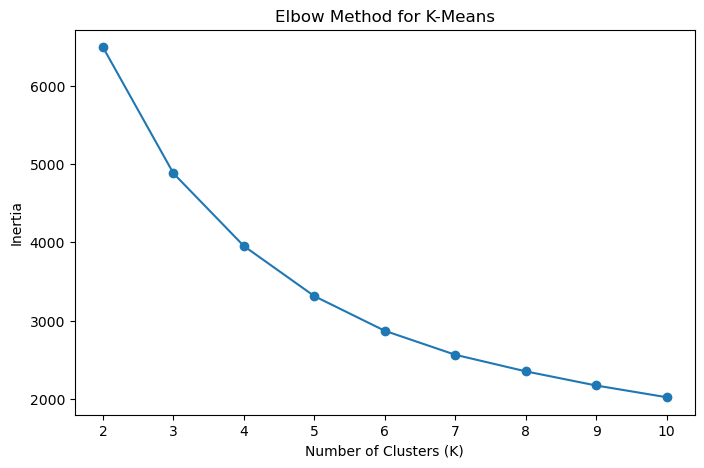

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()

In [44]:
from sklearn.cluster import KMeans
import joblib

# Final K-Means model
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Train the model
kmeans.fit(rfm_scaled)

# Add cluster labels to customer data
rfm['Cluster'] = kmeans.labels_

# Save the K-Means model
joblib.dump(
    kmeans,
    r'C:\Users\SHRAWANI\Downloads\Ecommerce_Customer_Segmentation\customer_segmentation_kmeans_model.pkl'
)

print("K-Means segmentation model saved successfully.")

K-Means segmentation model saved successfully.


In [45]:
# Save the scaler used for K-Means segmentation
joblib.dump(
    scaler,
    r'C:\Users\SHRAWANI\Downloads\Ecommerce_Customer_Segmentation\rfm_scaler.pkl'
)

print("RFM scaler saved successfully.")

RFM scaler saved successfully.


## Silhouette Score

In [46]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4325
K = 3: Silhouette Score = 0.3364
K = 4: Silhouette Score = 0.3369
K = 5: Silhouette Score = 0.3193
K = 6: Silhouette Score = 0.3140
K = 7: Silhouette Score = 0.3093
K = 8: Silhouette Score = 0.3035
K = 9: Silhouette Score = 0.2813
K = 10: Silhouette Score = 0.2768


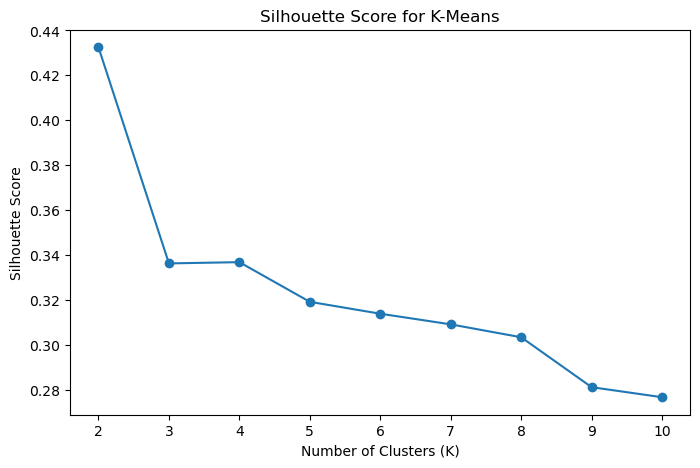

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.show()

In [48]:
cluster_results = {}

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    cluster_results[k] = labels
    
    print(f"\nK = {k}")
    print(pd.Series(labels).value_counts().sort_index())


K = 2
0    2672
1    1667
Name: count, dtype: int64

K = 3
0    1870
1     766
2    1703
Name: count, dtype: int64

K = 4
0     836
1    1186
2     717
3    1600
Name: count, dtype: int64

K = 5
0     843
1    1240
2     926
3     279
4    1051
Name: count, dtype: int64


In [49]:
for k in [2, 3, 4, 5]:
    
    temp_rfm = rfm.copy()
    temp_rfm['Cluster'] = cluster_results[k]
    
    profile = temp_rfm.groupby('Cluster').agg({
        'Recency': 'median',
        'Frequency': 'median',
        'Monetary': 'median'
    })
    
    print(f"\n{'='*50}")
    print(f"K = {k}")
    print(f"{'='*50}")
    print(profile.round(2))


K = 2
         Recency  Frequency  Monetary
Cluster                              
0           96.0        1.0    362.50
1           16.0        6.0   2059.45

K = 3
         Recency  Frequency  Monetary
Cluster                              
0          158.0        1.0    293.78
1            9.0       10.0   3696.86
2           30.0        3.0    974.52

K = 4
         Recency  Frequency  Monetary
Cluster                              
0           17.0        2.0    467.96
1           57.0        4.0   1331.48
2            8.0       10.0   3719.12
3          177.0        1.0    292.24

K = 5
         Recency  Frequency  Monetary
Cluster                              
0           23.0        2.0    362.06
1          207.0        1.0    250.02
2           15.0        6.0   2014.82
3            5.0       17.0   6910.78
4           78.0        3.0   1019.76


In [50]:
for k in [2, 3, 4, 5]:
    
    temp_rfm = rfm.copy()
    temp_rfm['Cluster'] = cluster_results[k]
    
    print(f"\nK = {k}")
    print(temp_rfm['Cluster'].value_counts().sort_index())


K = 2
Cluster
0    2672
1    1667
Name: count, dtype: int64

K = 3
Cluster
0    1870
1     766
2    1703
Name: count, dtype: int64

K = 4
Cluster
0     836
1    1186
2     717
3    1600
Name: count, dtype: int64

K = 5
Cluster
0     843
1    1240
2     926
3     279
4    1051
Name: count, dtype: int64


In [51]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

print("Final K-Means clustering completed.")
print("\nCluster Sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Final K-Means clustering completed.

Cluster Sizes:
Cluster
0     836
1    1186
2     717
3    1600
Name: count, dtype: int64


In [52]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median'
})

cluster_profile['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

print(cluster_profile.round(2))

         Recency  Frequency  Monetary  Customer_Count
Cluster                                              
0           17.0        2.0    467.96             836
1           57.0        4.0   1331.48            1186
2            8.0       10.0   3719.12             717
3          177.0        1.0    292.24            1600


In [53]:
segment_names = {
    0: 'Recent Low-Value Customers',
    1: 'Moderate Customers',
    2: 'High-Value Active Customers',
    3: 'At-Risk / Inactive Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print(rfm.head())

            Recency  Frequency  Monetary  Cluster  \
CustomerID                                          
12346           326          1  77183.60        1   
12347             2          7   4310.00        2   
12348            75          4   1797.24        1   
12349            19          1   1757.55        0   
12350           310          1    334.40        3   

                                 Segment  
CustomerID                                
12346                 Moderate Customers  
12347        High-Value Active Customers  
12348                 Moderate Customers  
12349         Recent Low-Value Customers  
12350       At-Risk / Inactive Customers  


In [54]:
print(rfm['Segment'].value_counts())

Segment
At-Risk / Inactive Customers    1600
Moderate Customers              1186
Recent Low-Value Customers       836
High-Value Active Customers      717
Name: count, dtype: int64


## Hierarchical clustering

In [55]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(rfm_scaled)

print("Hierarchical Clustering completed.")
print("\nCluster Sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Hierarchical Clustering completed.

Cluster Sizes:
0    1590
1    1227
2     930
3     592
Name: count, dtype: int64


In [56]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    rfm_scaled,
    hierarchical_labels
)

print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette:.4f}")

Hierarchical Clustering Silhouette Score: 0.2753


## DBSCAN

In [57]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(rfm_scaled)

print("DBSCAN Clustering completed.")

print("\nCluster Sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Clustering completed.

Cluster Sizes:
-1      63
 0    2791
 1    1485
Name: count, dtype: int64


In [58]:
from sklearn.metrics import silhouette_score

# Remove noise points (-1)
dbscan_mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    rfm_scaled[dbscan_mask],
    dbscan_labels[dbscan_mask]
)

print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")

DBSCAN Silhouette Score: 0.2930


In [59]:
rfm_dbscan = rfm.copy()

rfm_dbscan['DBSCAN_Cluster'] = dbscan_labels

dbscan_profile = rfm_dbscan.groupby('DBSCAN_Cluster').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median',
    'DBSCAN_Cluster': 'count'
})

dbscan_profile = dbscan_profile.rename(
    columns={'DBSCAN_Cluster': 'Customer_Count'}
)

print(dbscan_profile)

                Recency  Frequency  Monetary  Customer_Count
DBSCAN_Cluster                                              
-1                 10.0       15.0  28117.04              63
 0                 31.0        4.0   1131.56            2791
 1                133.0        1.0    255.91            1485


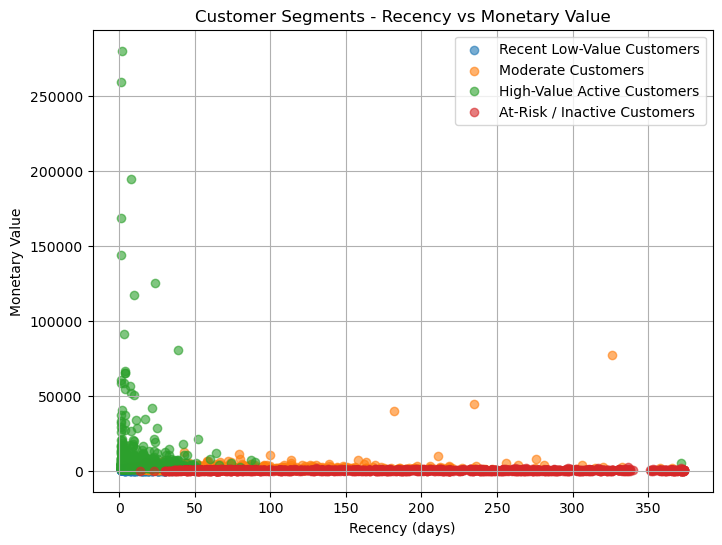

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['Recency'],
        cluster_data['Monetary'],
        label=segment_names[cluster],
        alpha=0.6
    )

plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value')
plt.title('Customer Segments - Recency vs Monetary Value')
plt.legend()
plt.grid(True)

plt.show()

# PREDICTION TARGET CREATION

In [61]:
prediction_date = pd.Timestamp('2011-10-10')
future_end_date = df['InvoiceDate'].max()

historical_df = df[df['InvoiceDate'] < prediction_date].copy()
future_df = df[df['InvoiceDate'] >= prediction_date].copy()

print("Historical data shape:", historical_df.shape)
print("Future data shape:", future_df.shape)

print("\nHistorical period:")
print(historical_df['InvoiceDate'].min(), "to", historical_df['InvoiceDate'].max())

print("\nFuture period:")
print(future_df['InvoiceDate'].min(), "to", future_df['InvoiceDate'].max())

Historical data shape: (276719, 9)
Future data shape: (116013, 9)

Historical period:
2010-12-01 08:26:00 to 2011-10-09 16:22:00

Future period:
2011-10-10 08:23:00 to 2011-12-09 12:50:00


In [62]:
# Customers who made purchases in the future period
future_customers = set(future_df['CustomerID'].unique())

# Customers who existed before the prediction date
historical_customers = historical_df['CustomerID'].unique()

# Create target for every historical customer
prediction_target = pd.DataFrame(
    index=historical_customers
)

prediction_target['Target'] = prediction_target.index.map(
    lambda customer: 0 if customer in future_customers else 1
)

print(prediction_target.head())

print("\nTarget Distribution:")
print(prediction_target['Target'].value_counts())

print("\nTarget Percentage:")
print(
    prediction_target['Target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

       Target
17850       1
13047       0
12583       0
13748       1
15100       1

Target Distribution:
Target
1    1928
0    1793
Name: count, dtype: int64

Target Percentage:
Target
1    51.81
0    48.19
Name: proportion, dtype: float64


In [63]:
prediction_features = historical_df.groupby('CustomerID').agg({
    'InvoiceDate': 'max',
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

prediction_features.columns = [
    'LastPurchaseDate',
    'Frequency',
    'Monetary'
]

# Calculate Recency relative to the prediction date
prediction_features['Recency'] = (
    prediction_date - prediction_features['LastPurchaseDate']
).dt.days

# Calculate Average Order Value
prediction_features['AverageOrderValue'] = (
    prediction_features['Monetary'] /
    prediction_features['Frequency']
)

# Keep only the features needed for the model
prediction_features = prediction_features[
    ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']
]

print(prediction_features.head())

print("\nFeature Shape:", prediction_features.shape)

print("\nMissing Values:")
print(prediction_features.isnull().sum())

            Recency  Frequency  Monetary  AverageOrderValue
CustomerID                                                 
12346           264          1  77183.60       77183.600000
12347            68          5   2790.86         558.172000
12348            14          4   1797.24         449.310000
12350           249          1    334.40         334.400000
12352            11          7   2194.31         313.472857

Feature Shape: (3721, 4)

Missing Values:
Recency              0
Frequency            0
Monetary             0
AverageOrderValue    0
dtype: int64


In [64]:
prediction_data = prediction_features.join(prediction_target)

print(prediction_data.head())

print("\nShape:", prediction_data.shape)

print("\nTarget Distribution:")
print(prediction_data['Target'].value_counts())

            Recency  Frequency  Monetary  AverageOrderValue  Target
CustomerID                                                         
12346           264          1  77183.60       77183.600000       1
12347            68          5   2790.86         558.172000       0
12348            14          4   1797.24         449.310000       1
12350           249          1    334.40         334.400000       1
12352            11          7   2194.31         313.472857       0

Shape: (3721, 5)

Target Distribution:
Target
1    1928
0    1793
Name: count, dtype: int64


In [65]:
X = prediction_data.drop('Target', axis=1)
y = prediction_data['Target']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (3721, 4)
y shape: (3721,)

Feature columns:
['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']

Target distribution:
Target
1    1928
0    1793
Name: count, dtype: int64


# TRAIN-TEST SPLIT

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (2976, 4)
Testing data shape: (745, 4)

Training target distribution:
Target
1    1542
0    1434
Name: count, dtype: int64

Testing target distribution:
Target
1    386
0    359
Name: count, dtype: int64


In [67]:
from sklearn.preprocessing import StandardScaler

scaler_prediction = StandardScaler()

X_train_scaled = scaler_prediction.fit_transform(X_train)
X_test_scaled = scaler_prediction.transform(X_test)

print("Training data scaled shape:", X_train_scaled.shape)
print("Testing data scaled shape:", X_test_scaled.shape)

Training data scaled shape: (2976, 4)
Testing data scaled shape: (745, 4)


# CLASSIFICATION MODEL COMPARISON

In [68]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [69]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions completed.")
print(y_pred_logistic[:10])

Predictions completed.
[1 1 1 0 1 0 1 1 1 1]


In [70]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully.")
print("Predictions completed.")
print(y_pred_dt[:10])

Decision Tree model trained successfully.
Predictions completed.
[1 0 0 1 1 0 1 1 0 1]


In [71]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")
print("Predictions completed.")
print(y_pred_rf[:10])

Random Forest model trained successfully.
Predictions completed.
[1 1 0 1 1 0 1 0 1 1]


In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

print("Gradient Boosting model trained successfully.")
print("Predictions completed.")
print(y_pred_gb[:10])

Gradient Boosting model trained successfully.
Predictions completed.
[1 1 1 0 1 0 1 1 1 1]


In [73]:
from sklearn.svm import SVC

svm_model = SVC(
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully.")
print("Predictions completed.")
print(y_pred_svm[:10])

SVM model trained successfully.
Predictions completed.
[1 1 1 0 1 0 1 1 1 1]


In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'SVM': y_pred_svm
}

results = []

for model_name, predictions in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1-Score': f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.671141   0.654267  0.774611  0.709371
1        Decision Tree  0.582550   0.600000  0.582902  0.591327
2        Random Forest  0.601342   0.613811  0.621762  0.617761
3    Gradient Boosting  0.664430   0.652466  0.753886  0.699519
4                  SVM  0.668456   0.648188  0.787565  0.711111


## CONFUSION MATRIX

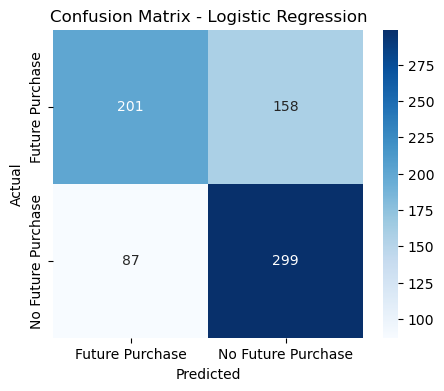

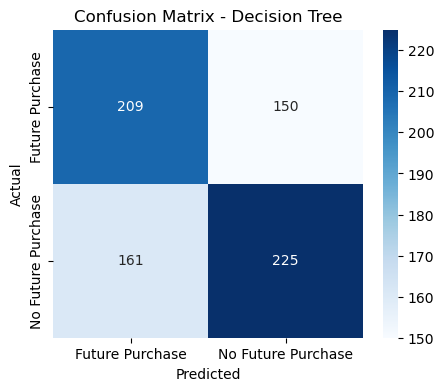

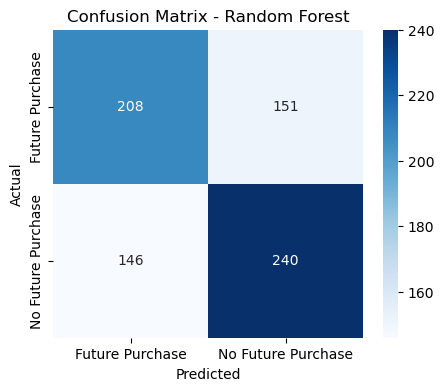

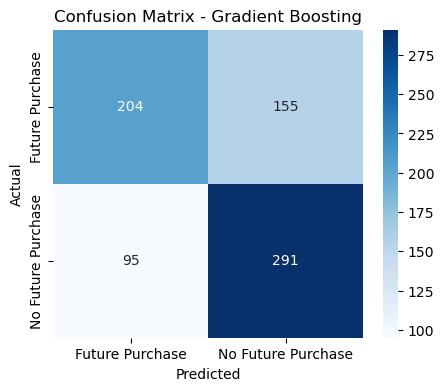

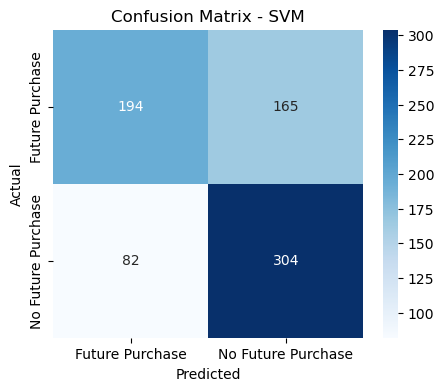

In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_predictions = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'SVM': y_pred_svm
}

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Future Purchase', 'No Future Purchase'],
        yticklabels=['Future Purchase', 'No Future Purchase']
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## ROC-AUC Score

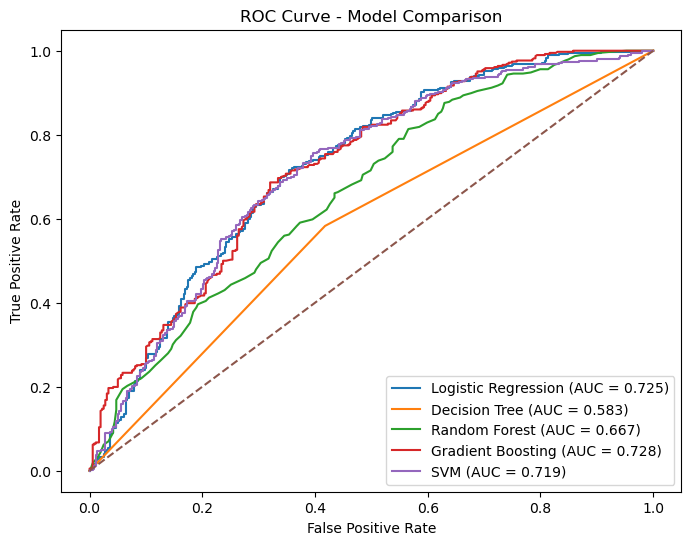

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities/scores
y_score_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_score_dt = decision_tree_model.predict_proba(X_test)[:, 1]
y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_score_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]
y_score_svm = svm_model.decision_function(X_test_scaled)

model_scores = {
    'Logistic Regression': y_score_logistic,
    'Decision Tree': y_score_dt,
    'Random Forest': y_score_rf,
    'Gradient Boosting': y_score_gb,
    'SVM': y_score_svm
}

plt.figure(figsize=(8, 6))

for model_name, scores in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_score = roc_auc_score(y_test, scores)

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.show()

In [77]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gradient_boosting_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
1          Frequency    0.529370
2           Monetary    0.167693
0            Recency    0.152750
3  AverageOrderValue    0.150186


## CROSS Validation

In [78]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:")
print(cv_scores)

print("\nMean CV F1-Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation F1 scores:
[0.7053701  0.72727273 0.70409712 0.72205438 0.71975498]

Mean CV F1-Score: 0.7157098606813392
Standard Deviation: 0.00929604454880173


In [79]:
import joblib

# Save Gradient Boosting model
joblib.dump(
    gradient_boosting_model,
    'gradient_boosting_customer_prediction_model.pkl'
)

# Save prediction scaler
joblib.dump(
    scaler_prediction,
    'prediction_scaler.pkl'
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [80]:
def predict_customer(recency, frequency, monetary, average_order_value):

    customer_data = pd.DataFrame({
        'Recency': [recency],
        'Frequency': [frequency],
        'Monetary': [monetary],
        'AverageOrderValue': [average_order_value]
    })

    prediction = gradient_boosting_model.predict(customer_data)

    if prediction[0] == 1:
        return "No Future Purchase"
    else:
        return "Future Purchase"


print(predict_customer(
    recency=10,
    frequency=8,
    monetary=3000,
    average_order_value=375
))

Future Purchase


In [81]:
final_customer_data = prediction_data.copy()

final_customer_data['Predicted_Status'] = gradient_boosting_model.predict(X)

final_customer_data['Predicted_Status'] = final_customer_data[
    'Predicted_Status'
].map({
    0: 'Future Purchase',
    1: 'No Future Purchase'
})

print(final_customer_data.head())
print("\nFinal Dataset Shape:", final_customer_data.shape)

            Recency  Frequency  Monetary  AverageOrderValue  Target  \
CustomerID                                                            
12346           264          1  77183.60       77183.600000       1   
12347            68          5   2790.86         558.172000       0   
12348            14          4   1797.24         449.310000       1   
12350           249          1    334.40         334.400000       1   
12352            11          7   2194.31         313.472857       0   

              Predicted_Status  
CustomerID                      
12346       No Future Purchase  
12347          Future Purchase  
12348          Future Purchase  
12350       No Future Purchase  
12352          Future Purchase  

Final Dataset Shape: (3721, 6)


In [82]:
# Get customer segments from the final K-Means model
customer_segments = rfm[['Segment']].copy()

# Merge segments with prediction results
final_customer_data = final_customer_data.join(
    customer_segments,
    how='left'
)

# Remove Target from the business-facing dataset
final_customer_data = final_customer_data.drop(columns=['Target'])

print(final_customer_data.head())
print("\nFinal Dataset Shape:", final_customer_data.shape)
print("\nSegment Distribution:")
print(final_customer_data['Segment'].value_counts())

            Recency  Frequency  Monetary  AverageOrderValue  \
CustomerID                                                    
12346           264          1  77183.60       77183.600000   
12347            68          5   2790.86         558.172000   
12348            14          4   1797.24         449.310000   
12350           249          1    334.40         334.400000   
12352            11          7   2194.31         313.472857   

              Predicted_Status                       Segment  
CustomerID                                                    
12346       No Future Purchase            Moderate Customers  
12347          Future Purchase   High-Value Active Customers  
12348          Future Purchase            Moderate Customers  
12350       No Future Purchase  At-Risk / Inactive Customers  
12352          Future Purchase            Moderate Customers  

Final Dataset Shape: (3721, 6)

Segment Distribution:
Segment
At-Risk / Inactive Customers    1431
Moderate Customer

## HISTORICAL CUSTOMER SEGMENTATION FOR PREDICTION

In [83]:
historical_rfm = historical_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (prediction_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

historical_rfm.columns = ['Recency', 'Frequency', 'Monetary']

historical_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,264,1,77183.60
12347,68,5,2790.86
12348,14,4,1797.24
12350,249,1,334.40
12352,11,7,2194.31


In [84]:
print("Historical RFM shape:", historical_rfm.shape)
print("\nMissing values:")
print(historical_rfm.isnull().sum())

historical_rfm.describe()

Historical RFM shape: (3721, 3)

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
count,3721.000000,3721.000000,3721.000000
mean,93.020425,3.675625,1743.043433
std,88.793445,6.265529,7284.768338
min,0.000000,1.000000,2.900000
25%,18.000000,1.000000,287.650000
50%,60.000000,2.000000,600.390000
75%,150.000000,4.000000,1452.680000
max,312.000000,146.000000,203948.190000


In [85]:
historical_rfm_log = np.log1p(historical_rfm)

In [86]:
scaler_hist = StandardScaler()
historical_rfm_scaled = scaler_hist.fit_transform(historical_rfm_log)

In [87]:
historical_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

historical_rfm['Cluster'] = historical_kmeans.fit_predict(
    historical_rfm_scaled
)

In [88]:
historical_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median()

,Recency,Frequency,Monetary
Cluster,,,
0,12.0,2.0,511.820
1,67.5,3.0,1101.005
2,12.0,9.0,3264.410
3,173.0,1.0,249.570


In [89]:
segment_names = {
    0: 'Recent Low-Value Customers',
    1: 'Moderate Customers',
    2: 'High-Value Active Customers',
    3: 'At-Risk / Inactive Customers'
}

historical_rfm['Segment'] = historical_rfm['Cluster'].map(segment_names)

In [90]:
historical_rfm = historical_rfm.drop(columns='Cluster')

In [91]:
prediction_data = prediction_data.join(
    historical_rfm[['Segment']],
    how='left'
)

prediction_data.head()

,Recency,Frequency,Monetary,AverageOrderValue,Target,Segment
CustomerID,,,,,,
12346,264,1,77183.60,77183.600000,1,Moderate Customers
12347,68,5,2790.86,558.172000,0,Moderate Customers
12348,14,4,1797.24,449.310000,1,Moderate Customers
12350,249,1,334.40,334.400000,1,At-Risk / Inactive Customers
12352,11,7,2194.31,313.472857,0,High-Value Active Customers


## FINAL CUSTOMER PREDICTIONS

In [92]:
final_customer_data = prediction_data.copy()

final_customer_data['Predicted_Status'] = gradient_boosting_model.predict(X)

final_customer_data['Predicted_Status'] = final_customer_data[
    'Predicted_Status'
].map({
    0: 'Future Purchase',
    1: 'No Future Purchase'
})

final_customer_data = final_customer_data.drop(columns='Target')

final_customer_data.head()

,Recency,Frequency,Monetary,AverageOrderValue,Segment,Predicted_Status
CustomerID,,,,,,
12346,264,1,77183.60,77183.600000,Moderate Customers,No Future Purchase
12347,68,5,2790.86,558.172000,Moderate Customers,Future Purchase
12348,14,4,1797.24,449.310000,Moderate Customers,Future Purchase
12350,249,1,334.40,334.400000,At-Risk / Inactive Customers,No Future Purchase
12352,11,7,2194.31,313.472857,High-Value Active Customers,Future Purchase


In [93]:
final_customer_data.groupby(
    ['Segment', 'Predicted_Status']
).size().unstack(fill_value=0)

Predicted_Status,Future Purchase,No Future Purchase
Segment,,
At-Risk / Inactive Customers,26,1369
High-Value Active Customers,575,2
Moderate Customers,639,377
Recent Low-Value Customers,225,508


## CUSTOMER SEGMENT VS PREDICTED BEHAVIOR

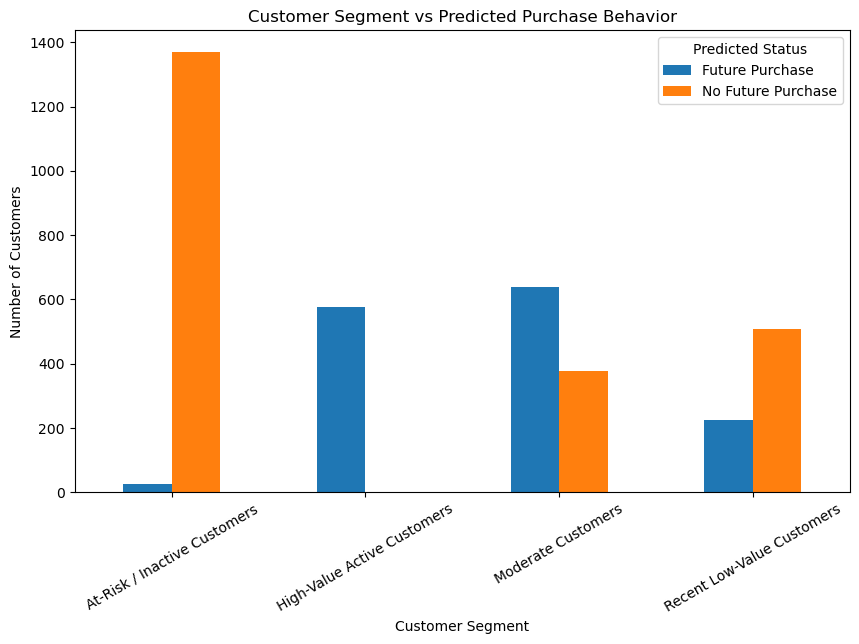

In [94]:
segment_prediction = final_customer_data.groupby(
    ['Segment', 'Predicted_Status']
).size().unstack(fill_value=0)

segment_prediction.plot(kind='bar', figsize=(10, 6))

plt.title('Customer Segment vs Predicted Purchase Behavior')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.legend(title='Predicted Status')
plt.show()

## FINAL CUSTOMER INSIGHTS

The customer-level analysis combines RFM-based customer segments with the predicted future purchase behavior.

- At-Risk / Inactive Customers show higher predicted no-future-purchase behavior, indicating a need for re-engagement campaigns.
- High-Value Active Customers are generally associated with future purchase predictions and can be targeted with loyalty and repeat-purchase strategies.
- Moderate Customers show mixed predicted behavior and can be targeted using personalized offers.
- Recent Low-Value Customers can be encouraged to make repeat purchases through onboarding offers and engagement campaigns.

## MODEL PERFORMANCE COMPARISON

In [95]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'SVM'
    ],
    'Accuracy': [0.6711, 0.5826, 0.6013, 0.6644, 0.6685],
    'Precision': [0.6543, 0.6000, 0.6138, 0.6525, 0.6482],
    'Recall': [0.7746, 0.5829, 0.6218, 0.7539, 0.7876],
    'F1-Score': [0.7094, 0.5913, 0.6178, 0.6995, 0.7111]
})

model_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.6711,0.6543,0.7746,0.7094
1,Decision Tree,0.5826,0.6000,0.5829,0.5913
2,Random Forest,0.6013,0.6138,0.6218,0.6178
3,Gradient Boosting,0.6644,0.6525,0.7539,0.6995
4,SVM,0.6685,0.6482,0.7876,0.7111


## FINAL CUSTOMER INSIGHTS

The customer-level analysis combines RFM-based customer segments with the predicted future purchase behavior.

- At-Risk / Inactive Customers show higher predicted no-future-purchase behavior, indicating a need for re-engagement campaigns.
- High-Value Active Customers are generally associated with future purchase predictions and can be targeted with loyalty and repeat-purchase strategies.
- Moderate Customers show mixed predicted behavior and can be targeted using personalized offers.
- Recent Low-Value Customers can be encouraged to make repeat purchases through onboarding offers and engagement campaigns.

## BUSINESS RECOMMENDATIONS

1. **At-Risk / Inactive Customers**
   - Use reactivation campaigns.
   - Provide personalized discounts or reminders.
   - Recommend products based on previous purchases.

2. **High-Value Active Customers**
   - Use loyalty programs.
   - Provide premium offers and early access to products.
   - Encourage repeat purchases.

3. **Moderate Customers**
   - Use personalized promotions.
   - Recommend related products.
   - Encourage customers to increase purchase frequency.

4. **Recent Low-Value Customers**
   - Encourage a second purchase.
   - Provide introductory offers.
   - Use product recommendations to increase engagement.

## CONCLUSION

This project developed an end-to-end e-commerce customer analytics solution using RFM analysis, customer segmentation, and machine learning prediction.

K-Means, Hierarchical Clustering, and DBSCAN were compared for customer segmentation. A time-based prediction approach was then developed to identify customers with no purchase in the future observation period.

Multiple classification models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Gradient Boosting was selected for the final project workflow, while model performance was evaluated on a separate test set.

The final output combines customer segments with predicted purchase behavior to support targeted marketing, customer retention, and business decision-making.

In [96]:
final_customer_data.to_csv(
    'final_customer_predictions.csv',
    index=True
)

print("Final customer dataset saved successfully.")

Final customer dataset saved successfully.


# Streamlit Deployment

The trained model has been deployed using Streamlit.

**Live Application:**  
https://ecommerce-customer-segmentation-and-prediction-ade2ktbjn8xdjlu.streamlit.app/